# Noise Sensitivity Sweep: Darcy Piecewise

- PDE: $-\nabla \cdot (a \nabla u) = 10$, piecewise constant coefficient function $\{5, 10\}$
- Latent dimension: $d = 200$
- Sweep: SNR $\in \{50, 35, 25, 15\}$ dB and clean baseline

In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "snr": n}
    for s, n in itertools.product([42, 123, 7], [None, 50, 35, 25, 15])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

In [2]:
import functools
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import numpyro

from src.problems.darcy_piecewise import DarcyPiecewise, mollifier, a_sample
from src.evaluation.metrics import rmse, cross_correlation
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95,
    plot_field_comparison, plot_calibration_overlay, plot_noise_sweep,
    plot_std_multi_panel, plot_sweep_summary_table, plot_trace,
    bootstrap_metric_ci, compute_error_std_correlation, chi2_ppc,
    compute_sigma_from_map, recommended_nuts_config,
    compute_prior_predictive, build_prior_result,
    make_nf_reparameterized_model,
    load_problem, get_nf_mode, make_log_prior,
    make_gaussian_log_likelihood,
    add_noise_snr_with_sigma,
    sample_unconditional_prior,
    run_mcmc, extract_mcmc_diagnostics,
    compute_piecewise_metrics,
    build_mcmc_result, save_experiment_result,
    load_cross_seed_results, cross_seed_metric_summary,
    run_map_estimation,
)

CHECKPOINT_PATH = Path('../runs/final_darcy_piecewise_updated_dims/weights/best.pt')
TRAIN_DATA_PATH = '../data/darcy_piecewise/pwc_train_data1000.mat'
TEST_DATA_PATH = '../data/darcy_piecewise/pwc_test_in.mat'
TEST_IDX = 0
N_OBS = 100
SNR_LEVELS = [50, 35, 25, 15]
NUM_WARMUP = 15000
NUM_SAMPLES = 5000
DECODE_BATCH = 500
NUM_CHAINS = 4
CHAIN_METHOD = 'sequential'
NF_ALPHA = 5.0

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
problem = DarcyPiecewise(
    seed=42,
    train_data_path=TRAIN_DATA_PATH,
    test_data_path=TEST_DATA_PATH,
)
params = load_problem(problem, CHECKPOINT_PATH)
beta_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

z_init = 0.5 * jnp.ones(d)

n_points = problem.get_n_points()
print(f"Latent dim: {d}")
print(f"z_init ready (d={d}, NF_ALPHA={NF_ALPHA})")

Loading data...


  Normalization: mean range [7.255, 7.775]
                 std range [2.485, 2.500]
  Train: a=(1000, 841, 1), u=(1000, 841, 1)


  Test: a=(200, 841, 1), u=(200, 841, 1)
Setting up grids and test functions...


  int_grid: (25, 2), v: (25, 1)
Building models...


  Initialized enc: 522,792 params


  Initialized u: 101,205 params


  Initialized a: 578,565 params
  Initialized s1: 101,205 params
  Initialized s2: 101,205 params


  Initialized nf: 1,260,240 params
Loading checkpoint: ../runs/final_darcy_piecewise_updated_dims/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded s1
  Loaded s2
  Loaded nf


Latent dim: 200
z_init ready (d=200, NF_ALPHA=5.0)


In [4]:
# Piecewise-specific decode (sigmoid + a_sample)
def decode_posterior_piecewise(beta_samples, a_true_ref, x_full):
    n_s = beta_samples.shape[0]
    a_pred_list, u_pred_list = [], []

    for i in range(0, n_s, DECODE_BATCH):
        batch = beta_samples[i:i+DECODE_BATCH]
        bs = batch.shape[0]
        x_tile = jnp.tile(x_full, (bs, 1, 1))

        u_pred = problem.models['u'].apply({'params': params['u']}, x_tile, batch)
        if u_pred.ndim == 2:
            u_pred = u_pred[..., None]
        u_pred = mollifier(u_pred.squeeze(-1), x_tile)
        u_pred_list.append(u_pred)

        a_logits = problem.models['a'].apply({'params': params['a']}, x_tile, batch)
        a_prob = jax.nn.sigmoid(a_logits)
        a_decoded = a_sample(a_prob[..., None])
        a_pred_list.append(a_decoded)

    a_pred = jnp.concatenate(a_pred_list, axis=0)
    u_pred = jnp.concatenate(u_pred_list, axis=0)

    a_true_np = np.array(a_true_ref[0, :, 0])
    a_np = np.array(a_pred[:, :, 0])

    pw_metrics = compute_piecewise_metrics(a_np, a_true_np, 5.0, 10.0, a_err_fn=cross_correlation)
    icorr = pw_metrics['a_err']

    spearman_rho, spearman_p = compute_error_std_correlation(
        a_true_np,
        np.array(jnp.mean(a_pred[:, :, 0], axis=0)),
        np.array(jnp.std(a_pred[:, :, 0], axis=0)),
    )

    return {
        'a_pred': a_pred, 'u_pred': u_pred,
        'a_mean': jnp.mean(a_pred, axis=0),
        'a_std': jnp.std(a_pred, axis=0),
        'u_mean': jnp.mean(u_pred, axis=0),
        'u_std': jnp.std(u_pred, axis=0),
        'icorr': icorr,
        'spearman_rho_error_std': spearman_rho,
        'spearman_pvalue_error_std': spearman_p,
        **{k: pw_metrics[k] for k in ('a_err', 'a_err_per_sample', 'crps_a', 'nll_a',
                                       'coverage_95', 'ci_width', 'mean_std',
                                       'cal_levels', 'cal_empirical')},
    }

## 2. Inversion Config

In [5]:
inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=1.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.1),
    scheduler=SchedulerConfig(type='StepLR', step_size=40, gamma=0.1),
)

## 3. Per-Seed Loop


######################################################################
# SEED = 42
######################################################################


x_obs: (1, 100, 2), u_obs_clean: (1, 100, 1)
a_true range: [5.0, 10.0] (expect {5, 10})


Prior predictive: a_err=0.5136, CRPS=1.2639, cov95=1.0000
  Inversion grid: n_mesh_or_grid=7, n_grid=25


Loss weights: pde=1.0, data=1.0, target=u


Inverting:   0%|          | 0/200 [00:00<?, ?it/s]

...

MCMC warmup: 1320.9s, sampling: 528.5s



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      z[0]      0.47      0.15      0.47      0.23      0.71  18199.82      1.00
      z[1]      0.49      0.15      0.49      0.25      0.74  18828.76      1.00
      z[2]      0.50      0.15      0.50      0.25      0.75  19855.87      1.00
      z[3]      0.50      0.15      0.50      0.25      0.75  19439.70      1.00
      z[4]      0.50      0.15      0.50      0.25      0.75  20690.48      1.00
      z[5]      0.49      0.15      0.49      0.24      0.74  19939.31      1.00
      z[6]      0.51      0.15      0.51      0.27      0.76  18191.74      1.00
      z[7]      0.51      0.15      0.51      0.26      0.75  19141.73      1.00
      z[8]      0.50      0.15      0.50      0.25      0.74  19486.65      1.00
      z[9]      0.50      0.15      0.50      0.25      0.75  20243.67      1.00
     z[10]      0.51      0.15      0.51      0.25      0.75  18039.93      1.00
     z[11]      0.50      0

ESS min=14780.6, R-hat max=1.0005, divergences=1/20000, [PASS] All diagnostics within thresholds


  Chi2 PPC: chi2=72.08, p=0.9841 (df=100)


Saved structured result to: /workspace/experiments/results/structured/noise_sweep/darcy_piecewise_2026-06-14T14-42-16_seed42.json

  Darcy Piecewise — Noise Sensitivity
  Condition                   I_corr     CRPS(a)    Coverage    CI Width   Sharpness     Diverg.     ESS min       R-hat    Flag
  ------------------------------------------------------------------------------------------------------------------------------
  Clean                     0.692045    0.998103    100.00%     4.322235    1.701127           1     14780.6      1.0005    PASS



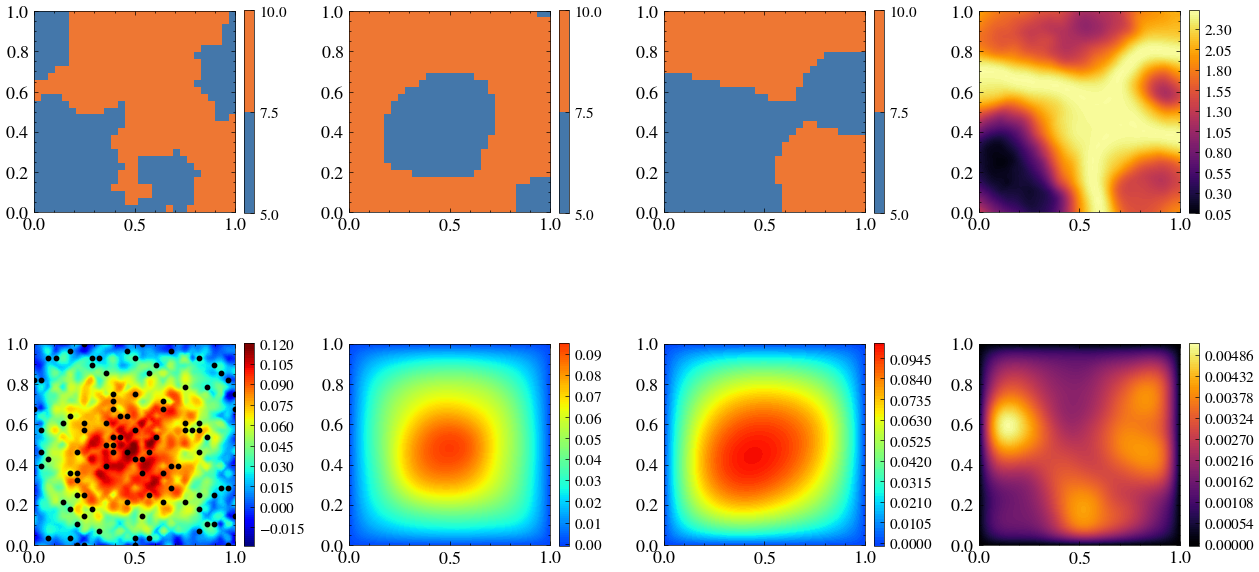


Bootstrap CIs on CRPS(a) at each condition:
         label      CRPS              95% CI


      SNR=15dB  0.99810  [0.99408, 1.00226]



SNR=15dB (sigma=0.011974):
  ESS (z-space): min=14780.6, mean=19083.1, median=19236.9
  R-hat (z-space): max=1.0005, mean=1.0000
  Dims with ESS < 10: 0 / 200
  Dims with R-hat > 1.1: 0 / 200
  Divergences: 1 / 20000
  Worst dims by R-hat (z-space):
   dim       ESS     R-hat
    45   19771.2    1.0005
    17   17823.9    1.0004
    19   16690.5    1.0003
    73   19093.3    1.0003
     0   18199.8    1.0003
   138   19492.7    1.0003
   186   17321.6    1.0003
   141   19061.5    1.0002
    46   19252.8    1.0002
   176   18970.4    1.0002


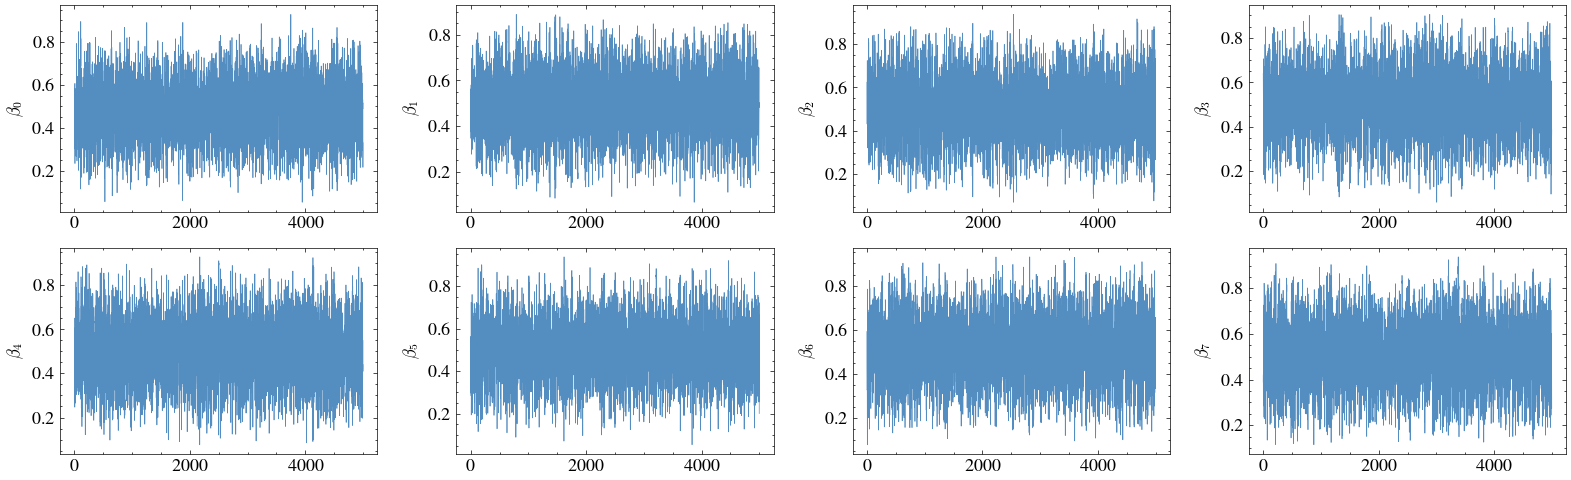

In [6]:
from results_schema import ExperimentResult
from datetime import datetime
from src.utils.PlotFigure import Plot

def _to_mcmc_result(res):
    return build_mcmc_result(res, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS)

for SEED in SEEDS:
    _t_total_start = time.time()
    print(f"\n{'#'*70}\n# SEED = {SEED}\n{'#'*70}")

    FIGURE_DIR = Path(f'figures/noise_sweep_darcy_piecewise/seed_{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    obs_indices = problem.sample_observation_indices(n_points, N_OBS, 'random', key)
    obs_data = problem.prepare_observations(sample_indices=[TEST_IDX], obs_indices=obs_indices)
    x_full = obs_data['x_full']
    x_obs = obs_data['x_obs']
    u_obs_clean = obs_data['u_obs']
    a_true = obs_data['a_true']
    u_true = obs_data['u_true']

    print(f"x_obs: {x_obs.shape}, u_obs_clean: {u_obs_clean.shape}")
    print(f"a_true range: [{float(a_true.min()):.1f}, {float(a_true.max()):.1f}] (expect {{5, 10}})")

    # ### Prior Predictive Baseline
    a_true_np = np.array(a_true[0, :, 0])
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
        error_fn=lambda pred, true: float(cross_correlation(
            jnp.array(np.where(pred >= 7.5, 10.0, 5.0)), jnp.array(true)
        )),
    )
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}")

    # ### MAP Baseline
    map_result = run_map_estimation(problem, params, x_obs, u_obs_clean, x_full, inv_config, rng)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    _map_time_s = map_result['time_s']
    rng = map_result['rng']

    print(f"MAP RMSE (a): {rmse(a_map, a_true[0]):.6f}")
    print("  (Note: RMSE is meaningless for piecewise constant fields — use I_corr instead)")
    icorr_map = float(cross_correlation(a_map, a_true[0]))
    print(f"MAP I_corr: {icorr_map:.6f}")

    preds_map_at_obs = problem.predict_from_beta(params, beta_map, x_obs)
    sigma_map = compute_sigma_from_map(preds_map_at_obs['u_pred'], u_obs_clean)
    print(f"sigma (MAP residual): {sigma_map:.6f}")

    h = map_result['loss_history']
    Plot.show_loss(
        [h['total'], h['weighted_pde'], h['weighted_data']],
        ['Total', f'PDE (×{inv_config.loss_weights.pde})', f'Data (×{inv_config.loss_weights.data})'],
        save_path=str(FIGURE_DIR / 'map_loss_curves.png'),
    )

    # ### Run conditions
    def run_condition(snr_db, rng_key):
        rng_key, noise_key, mcmc_key = random.split(rng_key, 3)

        if snr_db is not None:
            u_obs_noisy, noise_sigma = add_noise_snr_with_sigma(u_obs_clean, snr_db, noise_key)
            label = f"SNR={snr_db}dB"
            print(f"\n{'='*60}\n  {label} (noise_sigma={noise_sigma:.6f})\n{'='*60}")
        else:
            u_obs_noisy = u_obs_clean
            noise_sigma = None
            label = "Clean"
            print(f"\n{'='*60}\n  {label}\n{'='*60}")

        sigma = max(noise_sigma if noise_sigma is not None else 0.0, sigma_map)

        log_lik_fn = make_gaussian_log_likelihood(problem, params, mollifier, x_obs, u_obs_noisy)

        nf_model = make_nf_reparameterized_model(
            nf_model=problem.models['nf'],
            nf_params=params['nf'],
            log_likelihood_fn=log_lik_fn,
            d=d,
            nf_alpha=NF_ALPHA,
        )

        nuts_cfg = recommended_nuts_config(d, sigma)
        print(f"  sigma={sigma} | target_accept_prob={nuts_cfg['target_accept_prob']}, "
              f"max_tree_depth={nuts_cfg['max_tree_depth']}")

        mcmc, timing = run_mcmc(
            functools.partial(nf_model, sigma=sigma),
            {"z": z_init}, {}, mcmc_key,
            NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
        )
        mcmc.print_summary(exclude_deterministic=True)

        # Convert z -> beta via NF inverse
        z_01_s = mcmc.get_samples()["z"]
        z_s = 2.0 * z_01_s - 1.0
        beta_s, _ = problem.models['nf'].apply(
            {'params': params['nf']}, z_s, method=problem.models['nf'].inverse
        )

        # Diagnostics in z-space
        diag = extract_mcmc_diagnostics(mcmc, sample_name="z", total_samples=NUM_CHAINS * NUM_SAMPLES)

        dec = decode_posterior_piecewise(beta_s, a_true, x_full)

        # Chi-squared posterior predictive check
        u_np = np.array(dec['u_pred'][:, :, 0]) if dec['u_pred'].ndim == 3 else np.array(dec['u_pred'])
        u_pred_at_obs = u_np[:, np.array(obs_indices)]
        u_obs_np = np.array(u_obs_noisy[0, :, 0])
        chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, sigma)
        print(f"  Chi2 PPC: chi2={chi2_stat:.2f}, p={chi2_pval:.4f} (df={u_obs_np.shape[0]})")

        return {
            'label': label, 'snr_db': snr_db,
            'noise_sigma': noise_sigma, 'sigma': sigma,
            'beta_samples': np.array(beta_s),
            'beta_by_chain': diag['by_chain'],
            'beta_for_trace': diag['by_chain'][0],
            'a_pred_all': np.array(dec['a_pred'][:, :, 0]),
            'a_mean': np.array(dec['a_mean'][:, 0]),
            'a_std': np.array(dec['a_std'][:, 0]),
            'u_mean': np.array(dec['u_mean']),
            'u_std': np.array(dec['u_std']),
            'icorr': dec['icorr'],
            'ess_min': diag['ess_min'],
            'rhat_max': diag['rhat_max'],
            'rhat_mean': diag['rhat_mean'],
            'n_div': diag['n_div'],
            'reliability_flag': diag['flag'],
            'chi2_ppc': chi2_stat,
            'chi2_ppc_pvalue': chi2_pval,
            'spearman_rho_error_std': dec['spearman_rho_error_std'],
            'spearman_pvalue_error_std': dec['spearman_pvalue_error_std'],
            'warmup_time_s': timing['warmup_time_s'],
            'sampling_time_s': timing['sampling_time_s'],
            'step_time_s': timing['step_time_s'],
            **{k: dec[k] for k in ('a_err', 'a_err_per_sample', 'crps_a', 'nll_a',
                                    'coverage_95', 'ci_width', 'mean_std', 'cal_levels', 'cal_empirical')},
        }

    if _task_id is not None:
        _snr_iter = [PARAMETER_GRID[_task_id]["snr"]]
    else:
        _snr_iter = [None] + SNR_LEVELS

    _all_results = []
    for snr_db in _snr_iter:
        rng, key = random.split(rng)
        res = run_condition(snr_db, key)
        if snr_db is None:
            res['map_a_err'] = icorr_map
        _all_results.append(res)

    res_clean = next((r for r in _all_results if r['snr_db'] is None), None)
    sweep_results = [r for r in _all_results if r['snr_db'] is not None]

    experiment = ExperimentResult(
        experiment="noise_sweep",
        problem="darcy_piecewise",
        experiment_type="sweep",
        sweep_var="snr_db",
        seed=SEED,
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        prior=build_prior_result(prior_metrics),
        baseline=_to_mcmc_result(res_clean) if res_clean is not None else None,
        sweep_conditions=[_to_mcmc_result(r) for r in sweep_results],
        map_time_s=_map_time_s,
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    # ### Plots
    x_np = np.array(x_full[0])
    all_for_plot = ([res_clean] if res_clean is not None else []) + sweep_results
    all_labels = ['Clean'] + [f'SNR={s}dB' for s in SNR_LEVELS]
    plot_sweep_summary_table(all_for_plot, all_labels, title='Darcy Piecewise — Noise Sensitivity',
                             use_icorr=True)

    a_map_np = np.array(a_map[:, 0])
    u_map_np = np.array(map_result['u_map'][:, 0])
    for res in all_for_plot:
        if res['noise_sigma'] is not None:
            key_viz = random.PRNGKey(int(res['snr_db']))
            u_display = np.array((u_true + random.normal(key_viz, u_true.shape) * res['noise_sigma'])[0, :, 0])
        else:
            u_display = np.array(u_true[0, :, 0])
        plot_field_comparison(
            x_np,
            a_true=a_true_np,
            a_map=a_map_np,
            a_mean=res['a_mean'],
            a_std=res['a_std'],
            grid_shape=(29, 29),
            u_true=u_display,
            u_map=u_map_np,
            u_mean=res['u_mean'],
            u_std=res['u_std'],
            obs_coords=np.array(x_obs[0]),
            save_path=FIGURE_DIR / f'field_comparison_{res["label"].replace("=", "").replace(" ", "_").lower()}.png',
            show_abs_error=False,
            piecewise_a_bounds=(5.0, 10.0),
        )

    if res_clean is not None:
        plot_noise_sweep(sweep_results, baseline=res_clean, save_path=FIGURE_DIR / 'noise_sweep.png',
                         a_metric_key='icorr', a_metric_label='I_corr')

        stds = [res_clean['a_std']] + [r['a_std'] for r in sweep_results]
        std_labels = ['Clean'] + [r['label'] for r in sweep_results]
        plot_std_multi_panel(
            x_np, stds, std_labels, grid_shape=(29, 29),
            suptitle='Posterior Std: Noise Sensitivity (Piecewise)',
            save_path=FIGURE_DIR / 'std_multi_panel.png',
        )

        cal_list = [(res_clean['cal_levels'], res_clean['cal_empirical'], 'Clean')]
        for res in sweep_results:
            cal_list.append((res['cal_levels'], res['cal_empirical'], res['label']))
        plot_calibration_overlay(cal_list, save_path=FIGURE_DIR / 'calibration_overlay.png')

    def _crps_a(s, t): return float(np.mean(crps_ensemble(s, t)))

    rng_bs = np.random.default_rng(4)
    print("\nBootstrap CIs on CRPS(a) at each condition:")
    print(f"  {'label':>12s}  {'CRPS':>8s}  {'95% CI':>18s}")
    for res in all_for_plot:
        a_np = res['a_pred_all']
        ci = bootstrap_metric_ci(a_np, a_true_np, _crps_a, rng=rng_bs)
        print(f"  {res['label']:>12s}  {ci['estimate']:.5f}  [{ci['ci_lo']:.5f}, {ci['ci_hi']:.5f}]")

    # Piecewise-specific diagnostics: worst dims by R-hat in z-space
    from numpyro.diagnostics import effective_sample_size, split_gelman_rubin

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]
    beta_true_np = np.array(beta_true)
    for res in all_for_plot:
        beta_by_chain = res['beta_by_chain']
        ess = effective_sample_size(beta_by_chain)
        rhat = split_gelman_rubin(beta_by_chain)
        print(f"\n{res['label']} (sigma={res['sigma']:.6f}):")
        print(f"  ESS (z-space): min={float(ess.min()):.1f}, mean={float(ess.mean()):.1f}, median={float(np.median(ess)):.1f}")
        print(f"  R-hat (z-space): max={float(rhat.max()):.4f}, mean={float(rhat.mean()):.4f}")
        print(f"  Dims with ESS < 10: {int((ess < 10).sum())} / {d}")
        print(f"  Dims with R-hat > 1.1: {int((rhat > 1.1).sum())} / {d}")
        print(f"  Divergences: {res['n_div']} / {NUM_SAMPLES * NUM_CHAINS}")

        worst_dims = np.argsort(-np.array(rhat))[:10]
        print(f"  Worst dims by R-hat (z-space):")
        print(f"  {'dim':>4s}  {'ESS':>8s}  {'R-hat':>8s}")
        for i in worst_dims:
            print(f"  {i:4d}  {float(ess[i]):8.1f}  {float(rhat[i]):8.4f}")

        plot_trace(res['beta_for_trace'][:, :8], beta_true=None, num_warmup=0,
                   save_path=FIGURE_DIR / f'trace_{res["label"].replace("=", "").replace(" ", "_").lower()}.png')

## Cross-Seed Aggregation Summary

In [7]:
results = load_cross_seed_results("noise_sweep", "darcy_piecewise")
SUMMARY_METRICS = ["a_err", "crps_a", "nll_a", "coverage_95", "ci_width", "mean_std", "ess_min", "rhat_max", "n_div"]

if len(results) > 1:
    print(f"Cross-Seed Sweep Summary ({len(results)} seeds: {[r.seed for r in results]})\n")

    if results[0].baseline is not None:
        print("=== Baseline (Clean) ===")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in SUMMARY_METRICS:
            try:
                s = cross_seed_metric_summary(results, metric=m)
                if s["mean"] is not None:
                    print(f"{m:<16s}  {s['mean']:>10.4f}  {s['std']:>10.4f}  {s['min']:>10.4f}  {s['max']:>10.4f}")
            except (AttributeError, KeyError, TypeError):
                pass

    n_sweep = len(results[0].sweep_conditions) if results[0].sweep_conditions else 0
    for idx in range(n_sweep):
        label = results[0].sweep_conditions[idx].label or f"sweep[{idx}]"
        print(f"\n=== {label} ===")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in SUMMARY_METRICS:
            vals = []
            for r in results:
                if r.sweep_conditions and idx < len(r.sweep_conditions):
                    v = getattr(r.sweep_conditions[idx], m, None)
                    if v is not None:
                        vals.append(float(v))
            if vals:
                arr = np.array(vals)
                std_val = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0
                print(f"{m:<16s}  {float(np.mean(arr)):>10.4f}  {std_val:>10.4f}  {float(np.min(arr)):>10.4f}  {float(np.max(arr)):>10.4f}")
else:
    print(f"Only {len(results)} seed result(s) found - skipping cross-seed summary")

Cross-Seed Sweep Summary (35 seeds: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123])

=== Baseline (Clean) ===
Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.8393      0.0086      0.8303      0.8478
crps_a                0.7123      0.0182      0.6944      0.7315
nll_a                 0.4426      0.0072      0.4337      0.4496
coverage_95           1.0000      0.0000      1.0000      1.0000
ci_width              4.6051      0.0551      4.5660      4.6849
mean_std              1.9803      0.0157      1.9574      1.9900
ess_min           15473.0463   1484.5645  13649.1364  16924.5500
rhat_max              1.0004      0.0001      1.0003      1.0004
n_div                 0.0000      0.0000      0.0000      0.0000
